In [1]:
# @title 1a. Install kagglehub & mount Google Drive
!pip install -q kagglehub

from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import (
    classification_report,
    cohen_kappa_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from tqdm.auto import tqdm

sns.set_style("whitegrid")


def set_seed(seed: int = 42):
    """Set semua random seed agar hasil reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {DEVICE}")

Menggunakan device: cuda


In [3]:
# @title 4a. Download APTOS 2019 (kagglehub, sudah 224x224)
import kagglehub

aptos_path = kagglehub.dataset_download(
    "sovitrath/diabetic-retinopathy-224x224-2019-data"
)
print("Path to dataset files:", aptos_path)

# struktur dataset ini: <aptos_path>/train.csv + <aptos_path>/colored_images/<kelas>/<id_code>.png
!ls "{aptos_path}"

100%|██████████| 238M/238M [00:03<00:00, 69.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sovitrath/diabetic-retinopathy-224x224-2019-data/versions/4
colored_images	train.csv


In [4]:
# @title 4b. Copy dataset lokal dari Google Drive ke disk lokal Colab
import glob

# LOCAL_DR_DIR_DRIVE = "/content/drive/MyDrive/BayesianCNN/Dataset/Lokal"
# LOCAL_DR_DIR = "/content/data/local_raw"  # <- dari sini seterusnya, ini yang dipakai (bukan path Drive)

# def copy_drive_to_local(src_dir, dst_dir):
#     os.makedirs(dst_dir, exist_ok=True)
#     all_files = [f for f in glob.glob(os.path.join(src_dir, "**", "*"), recursive=True) if os.path.isfile(f)]
#     copied, skipped = 0, 0
#     for src_fp in tqdm(all_files, desc="Copy Drive -> lokal Colab"):
#         rel_path = os.path.relpath(src_fp, src_dir)
#         dst_fp = os.path.join(dst_dir, rel_path)
#         os.makedirs(os.path.dirname(dst_fp), exist_ok=True)
#         if os.path.exists(dst_fp) and os.path.getsize(dst_fp) == os.path.getsize(src_fp):
#             skipped += 1
#             continue
#         shutil.copy2(src_fp, dst_fp)
#         copied += 1
#     print(f"Selesai copy: {copied} file baru, {skipped} file sudah ada (di-skip, idempotent kalau re-run).")

# copy_drive_to_local(LOCAL_DR_DIR_DRIVE, LOCAL_DR_DIR)

# print("Isi folder lokal:")
# for cls in ["No_DR", "Mild", "Moderate", "Severe", "Proliferate_DR"]:
#     n = len(glob.glob(os.path.join(LOCAL_DR_DIR, cls, "*")))
#     print(f"  {cls}: {n} file")

In [5]:
# @title 5a. Build unified dataframe (APTOS + lokal, sama-sama struktur class_folders)
CLASS_ALIASES = {
    "No_DR": ["No_DR", "0"],
    "Mild": ["Mild", "1"],
    "Moderate": ["Moderate", "2"],
    "Severe": ["Severe", "3"],
    "Proliferate_DR": ["Proliferate_DR", "4"],
}


def load_class_folder_df(root_dir, source_name):
    rows = []
    for label, aliases in CLASS_ALIASES.items():
        folder_path = next(
            (
                os.path.join(root_dir, a)
                for a in aliases
                if os.path.isdir(os.path.join(root_dir, a))
            ),
            None,
        )
        if folder_path is None:
            continue
        for fp in glob.glob(os.path.join(folder_path, "*")):
            if fp.lower().endswith((".png", ".jpg", ".jpeg")):
                rows.append({"filepath": fp, "label": label, "source": source_name})
    return pd.DataFrame(rows)


aptos_df = load_class_folder_df(os.path.join(aptos_path, "colored_images"), "aptos")
print("Aptos")
print(aptos_df["label"].value_counts().sort_index())
print("\n")

# local_df = load_class_folder_df(LOCAL_DR_DIR, "local")
# print("Local")
# print(local_df["label"].value_counts().sort_index())
# print("\n")

full_df = pd.concat([aptos_df], ignore_index=True)
full_df = full_df[full_df["filepath"].apply(os.path.exists)].reset_index(drop=True)
df_shuffled = full_df.sample(frac=1, random_state=42).reset_index(drop=True)
print(
    "APTOS:",
    len(aptos_df),
    "| Local:",
    len([0]),
    "| combined (valid files):",
    len(df_shuffled),
)
print(df_shuffled["label"].value_counts().sort_index())

Aptos
label
Mild               370
Moderate           999
No_DR             1805
Proliferate_DR     295
Severe             193
Name: count, dtype: int64


APTOS: 3662 | Local: 1 | combined (valid files): 3662
label
Mild               370
Moderate           999
No_DR             1805
Proliferate_DR     295
Severe             193
Name: count, dtype: int64


In [6]:
# @title 6a. Preprocessing functions (revisi urutan)

import cv2


def _detect_retina_circle(gray, thresh=7):
    mask = gray > thresh
    if mask.sum() == 0:
        return None
    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0)
    return x0, y0, x1, y1


def _scale_radius(img, target_radius=300):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    row = gray[gray.shape[0] // 2, :]
    row_thresh = row > row.mean() / 10
    nz = np.nonzero(row_thresh)[0]
    if len(nz) < 2:
        return img
    current_radius = (nz[-1] - nz[0]) / 2
    if current_radius <= 1:
        return img
    scale = target_radius / current_radius
    scale = float(np.clip(scale, 0.1, 10.0))
    return cv2.resize(img, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)


def _circular_mask(img, radius_fraction=0.90):
    # standar Ben Graham: clip ke ~90% radius. SEKARANG dipanggil PALING TERAKHIR
    # (setelah semua operasi berbasis blur/tile), supaya blur besar di tahap
    # illumination-normalize tidak menyedot piksel hitam dari luar mask.
    h, w = img.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)
    center = (w // 2, h // 2)
    radius = int(min(h, w) / 2 * radius_fraction)
    cv2.circle(mask, center, radius, 255, -1)
    out = cv2.bitwise_and(img, img, mask=mask)
    return out


def _denoise(img, ksize=3):
    # median filter ringan: buang noise sebelum contrast enhancement
    return cv2.medianBlur(img, ksize)


def _local_average_subtract(img, sigma_fraction=30):
    # Ben Graham illumination normalization: img*4 - blur(img)*4 + 128
    # Dijalankan SEBELUM CLAHE dan SEBELUM circular mask.
    sigma = max(img.shape[0], img.shape[1]) / sigma_fraction
    blurred = cv2.GaussianBlur(img, (0, 0), sigma)
    out = cv2.addWeighted(img, 4, blurred, -4, 128)
    return out


def _clahe_lab(img_rgb, clip_limit=2.0, tile=(8, 8)):
    # CLAHE di L-channel (LAB), dijalankan SETELAH Ben Graham.
    # Ini menggantikan CLAHE-green-channel: ketiga channel RGB jadi diperlakukan
    # konsisten karena Ben Graham sebelumnya sudah menyentuh RGB secara merata.
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile)
    l_eq = clahe.apply(l)
    lab_eq = cv2.merge((l_eq, a, b))
    return cv2.cvtColor(lab_eq, cv2.COLOR_LAB2RGB)


def preprocess_image(img_rgb, img_size=224, target_radius=300, debug_stats=None):
    """Pipeline (urutan sudah direvisi):
    crop -> radius normalize -> denoise -> Ben Graham illumination normalize
    -> CLAHE (L-channel) -> circular mask (90%, TERAKHIR) -> pad -> resize.
    Fallback ke gambar original kalau ada stage yang gagal."""
    original = img_rgb
    try:
        gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
        box = _detect_retina_circle(gray, thresh=7)
        if box is not None:
            x0, y0, x1, y1 = box
            if (x1 - x0) > 10 and (y1 - y0) > 10:
                img_rgb = img_rgb[y0:y1, x0:x1]
        img_rgb = _scale_radius(img_rgb, target_radius=target_radius)
        img_rgb = _denoise(img_rgb, ksize=3)
        img_rgb = _local_average_subtract(img_rgb, sigma_fraction=30)
        img_rgb = _clahe_lab(img_rgb, clip_limit=2.0, tile=(8, 8))
        img_rgb = _circular_mask(img_rgb, radius_fraction=0.90)
    except Exception as e:
        img_rgb = original
        if debug_stats is not None:
            debug_stats["failed"] = debug_stats.get("failed", 0) + 1
            debug_stats.setdefault("errors", []).append(str(e))

    h, w = img_rgb.shape[:2]
    side = max(h, w)
    padded = np.zeros((side, side, 3), dtype=img_rgb.dtype)
    y_off, x_off = (side - h) // 2, (side - w) // 2
    padded[y_off : y_off + h, x_off : x_off + w] = img_rgb
    out = cv2.resize(padded, (img_size, img_size), interpolation=cv2.INTER_AREA)
    return out

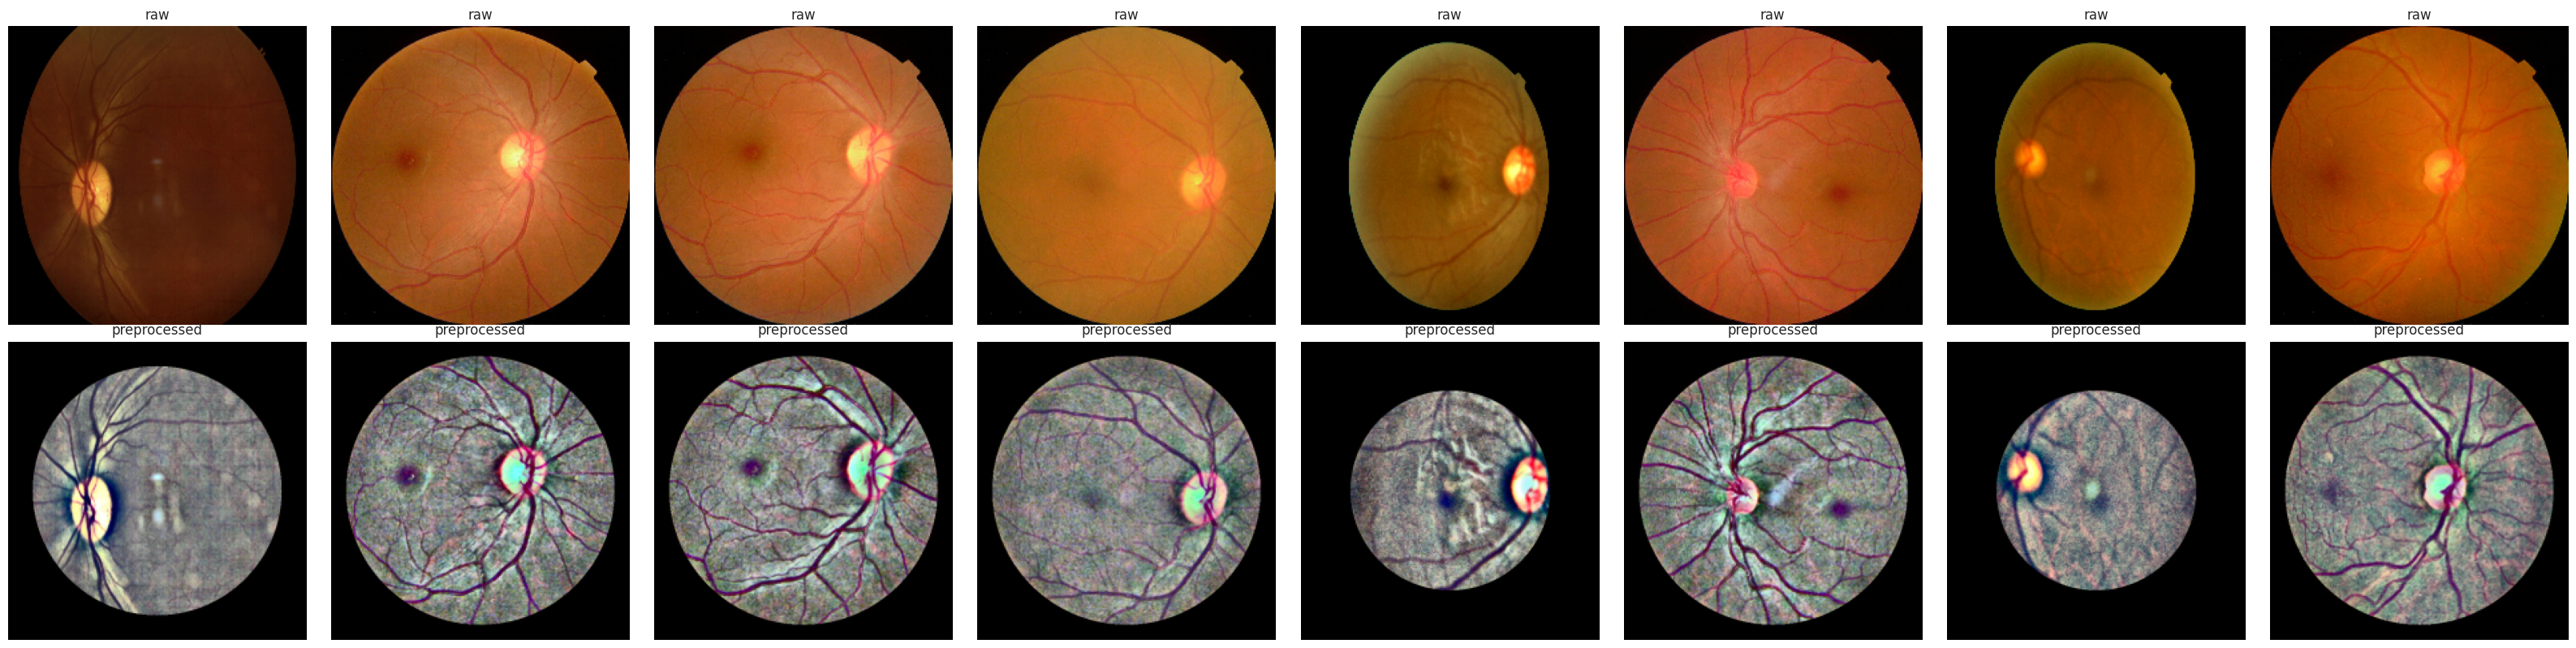

In [7]:
# @title 6b. Sanity check preprocessing on sample images
def _load_rgb(path):
    img = cv2.imread(path)
    if img is None:
        raise ValueError(f"Gagal membaca gambar (file korup/tidak didukung): {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


aptos_sample_paths = glob.glob(f"{aptos_path}/**/*.png", recursive=True)[:8]
if len(aptos_sample_paths) > 0:
    fig, axes = plt.subplots(
        2, len(aptos_sample_paths), figsize=(4 * len(aptos_sample_paths), 8)
    )
    for i, p in enumerate(aptos_sample_paths):
        raw = _load_rgb(p)
        proc = preprocess_image(raw)
        axes[0, i].imshow(raw)
        axes[0, i].set_title("raw")
        axes[0, i].axis("off")
        axes[1, i].imshow(proc)
        axes[1, i].set_title("preprocessed")
        axes[1, i].axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No sample aptos images found yet - run the download cells first.")

print("\n")

# local_sample_paths = glob.glob(f"{LOCAL_DR_DIR}/**/*.jpg", recursive=True)[:8]
# if len(local_sample_paths) > 0:
#     fig, axes = plt.subplots(2, len(local_sample_paths), figsize=(4 * len(local_sample_paths), 8))
#     for i, p in enumerate(local_sample_paths):
#         raw = _load_rgb(p)
#         proc = preprocess_image(raw)
#         axes[0, i].imshow(raw); axes[0, i].set_title("raw"); axes[0, i].axis("off")
#         axes[1, i].imshow(proc); axes[1, i].set_title("preprocessed"); axes[1, i].axis("off")
#     plt.tight_layout(); plt.show()
# else:
#     print("No sample local images found yet - run the download cells first.")

In [8]:
# @title 7a. Split dataset: train / val / test (stratified by label)

LABEL_TO_IDX = {"No_DR": 0, "Mild": 1, "Moderate": 2, "Severe": 3, "Proliferate_DR": 4}
IDX_TO_LABEL = {v: k for k, v in LABEL_TO_IDX.items()}

df_shuffled["label_idx"] = df_shuffled["label"].map(LABEL_TO_IDX)

train_df, temp_df = train_test_split(
    df_shuffled, test_size=0.30, stratify=df_shuffled["label_idx"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label_idx"], random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
for name, d in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"\nDistribusi label - {name}:")
    print(d["label"].value_counts().sort_index())

Train: 2563 | Val: 549 | Test: 550

Distribusi label - Train:
label
Mild               259
Moderate           699
No_DR             1263
Proliferate_DR     207
Severe             135
Name: count, dtype: int64

Distribusi label - Val:
label
Mild               55
Moderate          150
No_DR             271
Proliferate_DR     44
Severe             29
Name: count, dtype: int64

Distribusi label - Test:
label
Mild               56
Moderate          150
No_DR             271
Proliferate_DR     44
Severe             29
Name: count, dtype: int64


In [9]:
# @title 7b. PyTorch Dataset

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


class DRDataset(Dataset):
    def __init__(self, df, img_size=224, augment=False):
        self.df = df.reset_index(drop=True)
        self.img_size = img_size

        aug_list = []
        if augment:
            # augmentasi khusus fundus: flip horizontal & vertikal sama-sama valid
            # (retina tidak punya orientasi atas/bawah baku), rotasi bebas, jitter ringan
            aug_list += [
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomVerticalFlip(p=0.5),
                transforms.RandomRotation(degrees=25),
                transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
                transforms.RandomAffine(
                    degrees=0, translate=(0.05, 0.05), scale=(0.9, 1.1)
                ),
            ]
        aug_list += [
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ]
        self.transform = transforms.Compose(aug_list)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = _load_rgb(row["filepath"])
        img = preprocess_image(img, img_size=self.img_size)  # pipeline deterministik
        img = Image.fromarray(img)
        img = self.transform(img)
        return img, int(row["label_idx"])

In [14]:
# @title 8. DataLoader + WeightedRandomSampler
from torch.utils.data import WeightedRandomSampler

train_dataset = DRDataset(train_df, img_size=224, augment=True)
val_dataset = DRDataset(val_df, img_size=224, augment=False)
test_dataset = DRDataset(test_df, img_size=224, augment=False)

class_counts = train_df["label_idx"].value_counts().sort_index().values
class_weights = 1.0 / class_counts
sample_weights = train_df["label_idx"].map(lambda i: class_weights[i]).values

sampler = WeightedRandomSampler(
    sample_weights, num_samples=len(sample_weights), replacement=True
)

BATCH_SIZE = 64
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    pin_memory=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

print(
    f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}"
)

Train batches: 41 | Val batches: 9 | Test batches: 9


In [15]:
# @title 9. Bayesian DenseNet-121 (transfer learning + MC Dropout head)


class BayesianDenseNet121(nn.Module):
    def __init__(self, num_classes=5, dropout_p=0.4, freeze_backbone=False):
        super().__init__()
        backbone = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        self.features = backbone.features
        in_features = backbone.classifier.in_features  # 1024

        if freeze_backbone:
            for p in self.features.parameters():
                p.requires_grad = False

        self.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(
                p=dropout_p
            ),  # dropout ini yang di-sample ulang saat MC Dropout inference
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        feats = self.features(x)
        out = F.relu(feats, inplace=True)
        out = F.adaptive_avg_pool2d(out, (1, 1)).flatten(1)
        return self.classifier(out)


model = BayesianDenseNet121(num_classes=5, dropout_p=0.4, freeze_backbone=False).to(
    DEVICE
)
print(model)

BayesianDenseNet121(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  

In [16]:
# @title 10. Training loop
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=5e-5, weight_decay=5e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

EPOCHS = 30
best_val_loss = float("inf")
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{EPOCHS} [train]"):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    train_loss, train_acc = running_loss / total, correct / total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f"Epoch {epoch + 1}/{EPOCHS} [val]"):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += labels.size(0)
    val_loss, val_acc = val_loss / val_total, val_correct / val_total
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    print(
        f"Epoch {epoch + 1}: train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "/content/best_bcnn_densenet121.pt")
        print("  -> model tersimpan (val_loss membaik)")

Epoch 1/30 [train]:   0%|          | 0/41 [00:00<?, ?it/s]

Epoch 1/30 [val]:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch 1: train_loss=1.4321 train_acc=0.4151 val_loss=1.0665 val_acc=0.6248
  -> model tersimpan (val_loss membaik)


Epoch 2/30 [train]:   0%|          | 0/41 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ff2f0f0b600>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ff2f0f0b600>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

...

Epoch 20/30 [val]:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch 20: train_loss=0.2911 train_acc=0.9017 val_loss=0.6119 val_acc=0.7996


Epoch 21/30 [train]:   0%|          | 0/41 [00:10<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ff2f0f0b600>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ff2f0f0b600>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

KeyboardInterrupt: 

In [17]:
# @title 11. MC Dropout inference & uncertainty quantification
def enable_mc_dropout(model):
    """Aktifkan HANYA layer Dropout ke mode train (stochastic);
    layer lain (termasuk BatchNorm di backbone) tetap eval."""
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()


@torch.no_grad()
def predict_with_uncertainty(model, x, T=30, num_classes=5):
    model.eval()
    enable_mc_dropout(model)
    probs = torch.zeros(T, x.size(0), num_classes, device=x.device)
    for t in range(T):
        probs[t] = F.softmax(model(x), dim=1)

    mean_probs = probs.mean(dim=0)
    pred = mean_probs.argmax(dim=1)
    entropy = -(mean_probs * torch.log(mean_probs.clamp_min(1e-12))).sum(dim=1)
    entropy_norm = entropy / torch.log(torch.tensor(float(num_classes)))
    variance = probs.var(dim=0).mean(dim=1)
    return pred, mean_probs, entropy_norm, variance


model.load_state_dict(torch.load("/content/best_bcnn_densenet121.pt"))
all_preds, all_labels, all_entropy = [], [], []
for imgs, labels in tqdm(test_loader, desc="MC Dropout inference"):
    imgs = imgs.to(DEVICE)
    pred, mean_probs, entropy_norm, variance = predict_with_uncertainty(
        model, imgs, T=30
    )
    all_preds.extend(pred.cpu().numpy())
    all_labels.extend(labels.numpy())
    all_entropy.extend(entropy_norm.cpu().numpy())

print(
    classification_report(all_labels, all_preds, target_names=list(LABEL_TO_IDX.keys()))
)
print(
    f"QWK (Cohen's kappa, quadratic): {cohen_kappa_score(all_labels, all_preds, weights='quadratic'):.4f}"
)

MC Dropout inference:   0%|          | 0/9 [00:00<?, ?it/s]

                precision    recall  f1-score   support

         No_DR       0.97      0.95      0.96       271
          Mild       0.49      0.62      0.55        56
      Moderate       0.71      0.52      0.60       150
        Severe       0.31      0.72      0.44        29
Proliferate_DR       0.54      0.43      0.48        44

      accuracy                           0.75       550
     macro avg       0.60      0.65      0.61       550
  weighted avg       0.78      0.75      0.75       550

QWK (Cohen's kappa, quadratic): 0.8461
